<a href="https://colab.research.google.com/github/YakoYakoko/Estudios/blob/main/Alpha_beta_serchial_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== INICIO DEL ALGORITMO ALPHA-BETA ===

-> Visitando Nodo A | α = -inf, β = inf
-> Visitando Nodo B | α = -inf, β = inf
-> Visitando Nodo D | α = -inf, β = inf
   [Hoja alcanzada] Nodo D retorna valor = 3
   [Actualización MIN] Nodo B actualiza: Mejor = 3, β = 3
-> Visitando Nodo E | α = -inf, β = 3
   [Hoja alcanzada] Nodo E retorna valor = 5
   [Actualización MIN] Nodo B actualiza: Mejor = 3, β = 3
-> Visitando Nodo F | α = -inf, β = 3
   [Hoja alcanzada] Nodo F retorna valor = 6
   [Actualización MIN] Nodo B actualiza: Mejor = 3, β = 3
   [Actualización MAX] Nodo A actualiza: Mejor = 3, α = 3
-> Visitando Nodo C | α = 3, β = inf
-> Visitando Nodo G | α = 3, β = inf
   [Hoja alcanzada] Nodo G retorna valor = 9
   [Actualización MIN] Nodo C actualiza: Mejor = 9, β = 9
-> Visitando Nodo H | α = 3, β = 9
   [Hoja alcanzada] Nodo H retorna valor = 1
   [Actualización MIN] Nodo C actualiza: Mejor = 1, β = 1
   [¡PODA en Nodo C!] α (3) >= β (1). Recortando ramas restantes.
   [Actualizaci

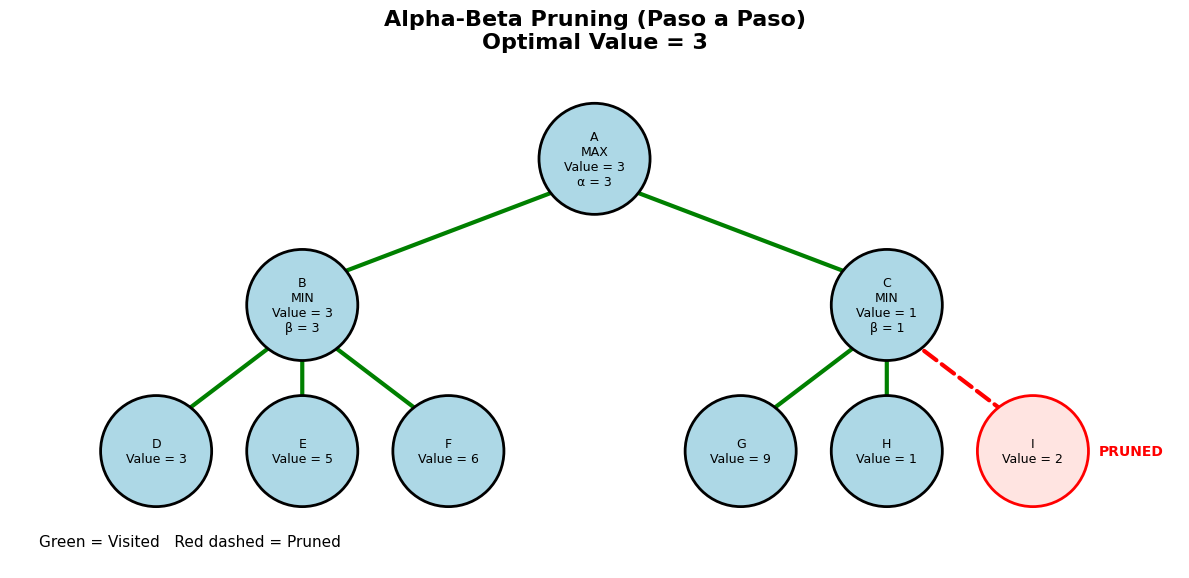

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

class Node:
    def __init__(self, name, children=None, value=None):
        self.name = name
        self.children = children or []
        self.value = value

# Valores originales (solo recorta 1 rama: el nodo I)
D = Node("D", value=3)
E = Node("E", value=5)
F = Node("F", value=6)

G = Node("G", value=9)
H = Node("H", value=1)
I = Node("I", value=2)

B = Node("B", children=[D, E, F])
C = Node("C", children=[G, H, I])

A = Node("A", children=[B, C])

visited_edges = []
pruned_edges = []
node_info = {}

def alpha_beta(node, depth, alpha, beta, maximizing):
    print(f"-> Visitando Nodo {node.name} | α = {alpha}, β = {beta}")

    if depth == 0 or node.value is not None:
        print(f"   [Hoja alcanzada] Nodo {node.name} retorna valor = {node.value}")
        return node.value

    children = node.children

    if maximizing:
        best_value = float("-inf")
        for i, child in enumerate(children):
            visited_edges.append((node.name, child.name))
            value = alpha_beta(child, depth - 1, alpha, beta, False)
            best_value = max(best_value, value)
            alpha = max(alpha, best_value)

            print(f"   [Actualización MAX] Nodo {node.name} actualiza: Mejor = {best_value}, α = {alpha}")

            if alpha >= beta:
                print(f"   [¡PODA en Nodo {node.name}!] α ({alpha}) >= β ({beta}). Recortando ramas restantes.")
                for remaining_child in children[i + 1:]:
                    pruned_edges.append((node.name, remaining_child.name))
                break

        node_info[node.name] = {"type": "MAX", "value": best_value, "alpha": alpha, "beta": beta}
        return best_value

    else:
        best_value = float("inf")
        for i, child in enumerate(children):
            visited_edges.append((node.name, child.name))
            value = alpha_beta(child, depth - 1, alpha, beta, True)
            best_value = min(best_value, value)
            beta = min(beta, best_value)

            print(f"   [Actualización MIN] Nodo {node.name} actualiza: Mejor = {best_value}, β = {beta}")

            if alpha >= beta:
                print(f"   [¡PODA en Nodo {node.name}!] α ({alpha}) >= β ({beta}). Recortando ramas restantes.")
                for remaining_child in children[i + 1:]:
                    pruned_edges.append((node.name, remaining_child.name))
                break

        node_info[node.name] = {"type": "MIN", "value": best_value, "alpha": alpha, "beta": beta}
        return best_value

print("=== INICIO DEL ALGORITMO ALPHA-BETA ===\n")
best_value = alpha_beta(A, 3, float("-inf"), float("inf"), True)
print(f"\nValor Óptimo Final = {best_value}")
print("\nAristas visitadas:", visited_edges)
print("Aristas podadas:", pruned_edges)
print("\nGenerando gráfica...")

positions = {
    "A": (0, 3),
    "B": (-2, 2),
    "C": (2, 2),
    "D": (-3, 1),
    "E": (-2, 1),
    "F": (-1, 1),
    "G": (1, 1),
    "H": (2, 1),
    "I": (3, 1)
}

leaf_values = {
    "D": 3,
    "E": 5,
    "F": 6,
    "G": 9,
    "H": 1,
    "I": 2
}

fig, ax = plt.subplots(figsize=(12, 7))

all_edges = [
    ("A", "B"),
    ("A", "C"),
    ("B", "D"),
    ("B", "E"),
    ("B", "F"),
    ("C", "G"),
    ("C", "H"),
    ("C", "I")
]

for parent, child in all_edges:
    x1, y1 = positions[parent]
    x2, y2 = positions[child]

    if (parent, child) in pruned_edges:
        edge_color = "red"
        edge_width = 3
        edge_style = "--"
    elif (parent, child) in visited_edges:
        edge_color = "green"
        edge_width = 3
        edge_style = "-"
    else:
        edge_color = "gray"
        edge_width = 2
        edge_style = "--"

    ax.add_patch(
        FancyArrowPatch(
            (x1, y1 - 0.12),
            (x2, y2 + 0.12),
            arrowstyle="-",
            linewidth=edge_width,
            linestyle=edge_style,
            color=edge_color
        )
    )

for name, (x, y) in positions.items():

    if name in node_info:
        info = node_info[name]

        label = (
            f"{name}\n"
            f"{info['type']}\n"
            f"Value = {info['value']}\n"
        )

        if info["type"] == "MAX":
            label += f"α = {info['alpha']}"
        else:
            label += f"β = {info['beta']}"

    else:
        label = f"{name}\nValue = {leaf_values[name]}"

    if any(child == name for _, child in pruned_edges):
        face_color = "mistyrose"
        edge_color = "red"
    else:
        face_color = "lightblue"
        edge_color = "black"

    circle = Circle(
        (x, y),
        0.38,
        facecolor=face_color,
        edgecolor=edge_color,
        linewidth=2
    )

    ax.add_patch(circle)

    ax.text(
        x,
        y,
        label,
        ha="center",
        va="center",
        fontsize=9
    )

for parent, child in pruned_edges:
    x, y = positions[child]

    ax.text(
        x + 0.45,
        y,
        "PRUNED",
        color="red",
        fontsize=10,
        fontweight="bold",
        va="center"
    )

ax.set_title(
    f"Alpha-Beta Pruning (Paso a Paso)\nOptimal Value = {best_value}",
    fontsize=16,
    fontweight="bold"
)

ax.text(
    -3.8,
    0.35,
    "Green = Visited   Red dashed = Pruned",
    fontsize=11
)

ax.set_xlim(-4, 4)
ax.set_ylim(0.2, 3.7)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

Condición cumplida: Se han podado 2 ramas. Generando gráfica...


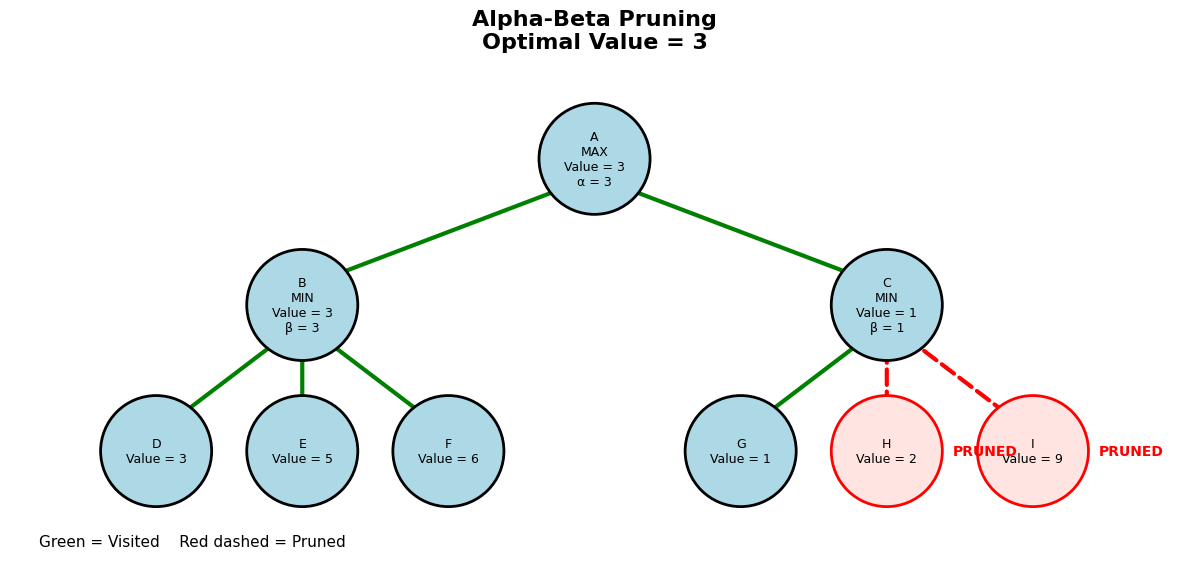

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch

class Node:
    def __init__(self, name, children=None, value=None):
        self.name = name
        self.children = children or []
        self.value = value

# Valores rotados/modificados para forzar la poda de 2 ramas en C
D = Node("D", value=3)
E = Node("E", value=5)
F = Node("F", value=6)

# Rotamos los valores: ahora G entra primero con un valor bajo para forzar poda temprana
G = Node("G", value=1)
H = Node("H", value=2)
I = Node("I", value=9)

B = Node("B", children=[D, E, F])
C = Node("C", children=[G, H, I])

A = Node("A", children=[B, C])

visited_edges = []
pruned_edges = []
node_info = {}

def alpha_beta(node, depth, alpha, beta, maximizing):
    if depth == 0 or node.value is not None:
        return node.value

    children = node.children

    if maximizing:
        best_value = float("-inf")
        for i, child in enumerate(children):
            visited_edges.append((node.name, child.name))
            value = alpha_beta(child, depth - 1, alpha, beta, False)
            best_value = max(best_value, value)
            alpha = max(alpha, best_value)

            if alpha >= beta:
                for remaining_child in children[i + 1:]:
                    pruned_edges.append((node.name, remaining_child.name))
                break

        node_info[node.name] = {"type": "MAX", "value": best_value, "alpha": alpha, "beta": beta}
        return best_value

    else:
        best_value = float("inf")
        for i, child in enumerate(children):
            visited_edges.append((node.name, child.name))
            value = alpha_beta(child, depth - 1, alpha, beta, True)
            best_value = min(best_value, value)
            beta = min(beta, best_value)

            if alpha >= beta:
                for remaining_child in children[i + 1:]:
                    pruned_edges.append((node.name, remaining_child.name))
                break

        node_info[node.name] = {"type": "MIN", "value": best_value, "alpha": alpha, "beta": beta}
        return best_value


best_value = alpha_beta(A, 3, float("-inf"), float("inf"), True)

# CONDICIÓN: Solo dar salida gráfica si se recortaron 2 ramas o más
if len(pruned_edges) >= 2:
    print(f"Condición cumplida: Se han podado {len(pruned_edges)} ramas. Generando gráfica...")

    positions = {
        "A": (0, 3), "B": (-2, 2), "C": (2, 2),
        "D": (-3, 1), "E": (-2, 1), "F": (-1, 1),
        "G": (1, 1), "H": (2, 1), "I": (3, 1)
    }

    leaf_values = {"D": 3, "E": 5, "F": 6, "G": 1, "H": 2, "I": 9}

    fig, ax = plt.subplots(figsize=(12, 7))

    all_edges = [
        ("A", "B"), ("A", "C"), ("B", "D"), ("B", "E"),
        ("B", "F"), ("C", "G"), ("C", "H"), ("C", "I")
    ]

    for parent, child in all_edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]

        if (parent, child) in pruned_edges:
            edge_color, edge_width, edge_style = "red", 3, "--"
        elif (parent, child) in visited_edges:
            edge_color, edge_width, edge_style = "green", 3, "-"
        else:
            edge_color, edge_width, edge_style = "gray", 2, "--"

        ax.add_patch(
            FancyArrowPatch((x1, y1 - 0.12), (x2, y2 + 0.12), arrowstyle="-",
                            linewidth=edge_width, linestyle=edge_style, color=edge_color)
        )

    for name, (x, y) in positions.items():
        if name in node_info:
            info = node_info[name]
            label = f"{name}\n{info['type']}\nValue = {info['value']}\n"
            label += f"α = {info['alpha']}" if info["type"] == "MAX" else f"β = {info['beta']}"
        else:
            label = f"{name}\nValue = {leaf_values[name]}"

        if any(child == name for _, child in pruned_edges):
            face_color, edge_color_circle = "mistyrose", "red"
        else:
            face_color, edge_color_circle = "lightblue", "black"

        circle = Circle((x, y), 0.38, facecolor=face_color, edgecolor=edge_color_circle, linewidth=2)
        ax.add_patch(circle)
        ax.text(x, y, label, ha="center", va="center", fontsize=9)

    for parent, child in pruned_edges:
        x, y = positions[child]
        ax.text(x + 0.45, y, "PRUNED", color="red", fontsize=10, fontweight="bold", va="center")

    ax.set_title(f"Alpha-Beta Pruning\nOptimal Value = {best_value}", fontsize=16, fontweight="bold")
    ax.text(-3.8, 0.35, "Green = Visited    Red dashed = Pruned", fontsize=11)

    ax.set_xlim(-4, 4)
    ax.set_ylim(0.2, 3.7)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print(f"Condición NO cumplida: Solo se podaron {len(pruned_edges)} ramas. No se generará la gráfica.")